# GeoLife CP1 — Same-second × Transportation Audit

**Mục tiêu:** kiểm chứng assumption Stage 2 sau góp ý mentor: `max_radius_m > 10 m` có luôn là spatial corruption/conflict, hay một phần là **timestamp-resolution ambiguity** trong các mode tốc độ cao.

Notebook này **không thay đổi production cleaning**. Nó chỉ tạo evidence để quyết định có amend contract hay không.

## Audit này đang kiểm tra điều gì?

GeoLife chỉ lưu timestamp tới **whole second**. Vì vậy hai observations thật có thể xảy ra ở hai thời điểm khác nhau bên trong cùng một giây nhưng vẫn được ghi cùng timestamp:

```text
thời gian thật              timestamp trong release
12:00:00.10  P1   ┐
                  ├──→      12:00:00  P1
12:00:00.90  P2   ┘         12:00:00  P2
```

Ta không biết `P1` hay `P2` xảy ra trước từ release này.

Audit không hỏi “hai điểm >10m có chắc chắn hợp lệ không?”. Nó hỏi câu hẹp hơn:

> **Có evidence cho thấy một số group >10m có thể tương thích với chuyển động thật, nên không được mặc định gọi tất cả chúng là corruption hay không?**

Flow:

```text
212,409 same-second groups
        ↓
835 groups có max_radius_m > 10m
        ↓
reconstruct exact diameter
        ↓
join transportation labels theo [start, end)
        ↓
so sánh spatial spread theo mode
        ↓
so với distance-scale quan sát được từ speed benchmark
        ↓
quyết định semantics của threshold 10m
```

Transportation labels chỉ dùng như **audit evidence**. Production cleaning không được phụ thuộc vào mode label.

### Câu hỏi cụ thể

1. Trong 835 same-second groups có `max_radius_m > 10 m`, bao nhiêu group có transportation label unambiguous?
2. Distribution của `max_radius_m` và exact group diameter theo mode là gì?
3. Fast modes như train/subway có xuất hiện trong vùng spread vài chục mét không?
4. Bao nhiêu conflict nằm trong vùng `diameter <= 333.3 m` — broad envelope tương ứng 1200 km/h trong 1 giây?
5. Evidence có đủ để đổi semantics từ “>10m = spatial corruption” thành “>10m = unsafe-to-collapse / ordering ambiguity boundary” hay không?

> **Quan trọng:** airplane là motivating example của mentor, nhưng audit chỉ có thể kết luận trực tiếp về airplane nếu trong 835 groups thực sự có airplane label unambiguous.

In [1]:
from pathlib import Path
from time import perf_counter
from IPython.display import display
import os, subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_URL = "https://github.com/tanh1c/geolife.git"
REPO_BRANCH = os.environ.get("GEOLIFE_REPO_BRANCH", "cp1-cleaning-staypoint")
REPO_DIR = Path(os.environ.get("GEOLIFE_REPO_DIR", "/tmp/geolife"))
VOLUME_ROOT = Path("/mnt/geolife-data")
AUDIT_CACHE_DIR = VOLUME_ROOT / "cache" / "cp1_same_second_transport"
AUDIT_CACHE_DIR.mkdir(parents=True, exist_ok=True)

def resolve_data_root():
    env_root = os.environ.get("GEOLIFE_DATA_ROOT")
    candidates = ([Path(env_root)] if env_root else []) + [
        VOLUME_ROOT / "extracted" / "Geolife Trajectories 1.3" / "Data",
        VOLUME_ROOT / "Data",
    ]
    for candidate in candidates:
        if candidate.is_dir() and any(candidate.glob("*/Trajectory/*.plt")):
            return candidate
    for candidate in sorted(VOLUME_ROOT.glob("**/Data")):
        if candidate.is_dir() and any(candidate.glob("*/Trajectory/*.plt")):
            return candidate
    raise FileNotFoundError("GeoLife Data folder not found")

def ensure_repo():
    if (REPO_DIR / ".git").exists():
        subprocess.run(["git", "-C", str(REPO_DIR), "fetch", "origin"], check=True)
        subprocess.run(["git", "-C", str(REPO_DIR), "checkout", REPO_BRANCH], check=True)
        subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only", "origin", REPO_BRANCH], check=True)
    else:
        subprocess.run(["git", "clone", "--branch", REPO_BRANCH, REPO_URL, str(REPO_DIR)], check=True)

DATA_ROOT = resolve_data_root()
ensure_repo()
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

from notebooks.eda_core import inventory_dataset, read_plt, read_labels, haversine_vectorized

print("Repo:", REPO_DIR)
print("Branch:", REPO_BRANCH)
print("Data root:", DATA_ROOT)
print("Audit cache:", AUDIT_CACHE_DIR)

Cloning into '/tmp/geolife'...


Repo: /tmp/geolife
Branch: cp1-cleaning-staypoint
Data root: /mnt/geolife-data/extracted/Geolife Trajectories 1.3/Data
Audit cache: /mnt/geolife-data/cache/cp1_same_second_transport


## 1. Reuse same-second EDA cache

EDA trước đã đo **212,409 same-second groups**, trong đó **835 groups có max_radius_m > 10 m**.

Ta reuse cache đó thay vì đọc lại toàn release.

In [2]:
preferred = VOLUME_ROOT / "eda_cache" / "same_second_groups_v1.pkl"
if preferred.exists():
    SAME_SECOND_CACHE = preferred
else:
    matches = sorted(VOLUME_ROOT.glob("**/same_second_groups_v1.pkl"))
    if not matches:
        raise FileNotFoundError("Không tìm thấy same_second_groups_v1.pkl từ EDA trước.")
    SAME_SECOND_CACHE = matches[0]

same_second = pd.read_pickle(SAME_SECOND_CACHE).copy()
same_second["timestamp"] = pd.to_datetime(same_second["timestamp"], utc=True)
conflicts = same_second.loc[same_second["max_radius_m"] > 10.0].copy()
conflicts = conflicts.sort_values(["user_id","trajectory_id","timestamp"], kind="stable").reset_index(drop=True)

print("Loaded:", SAME_SECOND_CACHE)
print("Same-second groups:", f"{len(same_second):,}")
print("Groups >10m:", f"{len(conflicts):,}")
display(conflicts[["group_size","unique_positions","max_radius_m","median_radius_m"]]
        .describe(percentiles=[.5,.75,.9,.95,.99]))

assert len(same_second) == 212_409
assert len(conflicts) == 835

Loaded: /mnt/geolife-data/eda_cache/same_second_groups_v1.pkl
Same-second groups: 212,409
Groups >10m: 835


,group_size,unique_positions,max_radius_m,median_radius_m
count,835.000000,835.000000,835.000000,835.000000
mean,3.600000,3.535329,24427.910733,24130.353764
std,1.526897,1.507657,92591.819144,91899.949183
min,2.000000,2.000000,10.000046,0.000000
50%,4.000000,4.000000,15.789926,9.239646
75%,5.000000,5.000000,37.785740,17.505957
90%,5.000000,5.000000,269.729265,133.101384
95%,5.000000,5.000000,310469.209118,308706.723342
99%,6.000000,6.000000,429097.828650,425202.033293
max,14.000000,14.000000,430206.033536,426293.640895


### Cách đọc tail >10m

Trong 835 groups:

- median `max_radius_m` chỉ khoảng **15.8m** → phần lớn conflicts chỉ vừa vượt 10m;
- nhưng p95 nhảy lên khoảng **310 km** và max khoảng **430 km** → tồn tại một extreme tail rất khác bản chất.

Đây là lý do audit không nên dùng một câu giải thích duy nhất cho mọi `>10m` group.

Ta cần tách hai câu hỏi:

```text
Q1. Có safe để collapse không?        → 10m threshold
Q2. Nguyên nhân spread là gì?         → audit; thường không xác định chắc chắn
```

## 2. Reconstruct exact group diameter for the 835 conflicts

EDA trước dùng `max_radius_m`:

```text
P1 -------- M -------- P2
      20m       20m
```

Nếu `M` là median center thì:

```text
max_radius_m ≈ 20m
```

Nhưng để hỏi “hai observations xa nhau bao nhiêu trong cùng recorded second?”, đại lượng trực quan hơn là:

```text
diameter_m = max pairwise Haversine distance inside the group
           ≈ 40m trong ví dụ trên
```

Vì vậy notebook đọc lại **chỉ các trajectory chứa 835 groups >10m** và tính exact pairwise diameter. Ta không scan lại toàn bộ 24.9M raw points.

### Cách đọc output của section này

Run hiện tại cho:

- median `max_radius_m` ≈ **15.79m**;
- median `diameter_m` ≈ **23.58m**;
- p90 `diameter_m` ≈ **388.74m**;
- p95 `diameter_m` ≈ **617 km**;
- max `diameter_m` ≈ **852 km**.

Mean rất lớn vì tail có một số group cực đoan. Đây là dấu hiệu đầu tiên rằng `>10m` **không phải một population đồng nhất**: phần lớn chỉ hơi vượt 10m, nhưng một tail nhỏ nhảy sang hàng trăm km.

Do đó ở các section sau ta cần phân biệt:

```text
vài chục mét  ≠  hàng trăm km
```

thay vì gộp tất cả thành một nhãn “conflict” có cùng ý nghĩa.

In [3]:
inventory, all_files = inventory_dataset(DATA_ROOT)
file_map = {(user_id, path.stem): path for user_id, path in all_files}
DIAMETER_CACHE = AUDIT_CACHE_DIR / "same_second_conflict_diameter_v1.pkl"

def exact_group_diameter(group):
    coords = group[["latitude","longitude"]].drop_duplicates().to_numpy(dtype=float)
    if len(coords) < 2:
        return 0.0
    best = 0.0
    for i in range(len(coords)-1):
        d = haversine_vectorized(
            np.full(len(coords)-i-1, coords[i,0]),
            np.full(len(coords)-i-1, coords[i,1]),
            coords[i+1:,0], coords[i+1:,1],
        )
        if len(d):
            best = max(best, float(np.nanmax(d)))
    return best

if DIAMETER_CACHE.exists():
    conflict_detail = pd.read_pickle(DIAMETER_CACHE)
    print("Loaded:", DIAMETER_CACHE)
else:
    rows = []
    grouped_targets = conflicts.groupby(["user_id","trajectory_id"], sort=False)
    t0 = perf_counter()
    for idx, ((user_id, trajectory_id), targets) in enumerate(grouped_targets, 1):
        path = file_map[(str(user_id), str(trajectory_id))]
        raw = read_plt(path)
        target_times = set(pd.to_datetime(targets["timestamp"], utc=True))
        subset = raw.loc[raw["timestamp"].isin(target_times), ["timestamp","latitude","longitude"]]
        by_ts = {ts:g for ts,g in subset.groupby("timestamp", sort=False)}

        for row in targets.itertuples(index=False):
            group = by_ts.get(row.timestamp)
            if group is None or group.empty:
                raise RuntimeError(f"Cannot reconstruct {user_id}/{trajectory_id} {row.timestamp}")
            rows.append({
                "user_id": str(user_id),
                "trajectory_id": str(trajectory_id),
                "timestamp": row.timestamp,
                "group_size": int(row.group_size),
                "unique_positions": int(row.unique_positions),
                "max_radius_m": float(row.max_radius_m),
                "median_radius_m": float(row.median_radius_m),
                "diameter_m": exact_group_diameter(group),
            })
        if idx % 100 == 0:
            print(f"{idx:,}/{len(grouped_targets):,} affected trajectories | {(perf_counter()-t0)/60:.1f} min")

    conflict_detail = pd.DataFrame(rows)
    conflict_detail.to_pickle(DIAMETER_CACHE)
    print("Saved:", DIAMETER_CACHE)

display(conflict_detail[["max_radius_m","diameter_m"]].describe(percentiles=[.5,.75,.9,.95,.99]))
assert len(conflict_detail) == 835

Loaded: /mnt/geolife-data/cache/cp1_same_second_transport/same_second_conflict_diameter_v1.pkl


,max_radius_m,diameter_m
count,835.000000,835.000000
mean,24427.910733,48404.125465
std,92591.819144,183742.305490
min,10.000046,10.324375
50%,15.789926,23.581546
75%,37.785740,54.551045
90%,269.729265,388.737510
95%,310469.209118,617322.086558
99%,429097.828650,850096.901822
max,430206.033536,852277.709621


## 3. Transportation labels theo half-open `[start, end)`

- `start <= timestamp < end`
- nhiều distinct active modes → `ambiguous_label`
- user có labels nhưng timestamp ngoài mọi interval → `labeled_user_unlabeled_time`
- user không có labels → `unlabeled_user`

In [4]:
label_parts = []
for user_dir in sorted(p for p in DATA_ROOT.iterdir() if p.is_dir() and p.name.isdigit()):
    label_path = user_dir / "labels.txt"
    if label_path.exists():
        part = read_labels(label_path, user_dir.name)
        if not part.empty:
            label_parts.append(part)

labels_all = pd.concat(label_parts, ignore_index=True)
label_users = set(labels_all["user_id"].astype(str))
labels_by_user = {
    str(uid): g.sort_values(["start_time","end_time"], kind="stable").reset_index(drop=True)
    for uid, g in labels_all.groupby("user_id")
}

def active_modes_at_timestamp(user_labels, timestamp):
    active = user_labels.loc[
        (user_labels["start_time"] <= timestamp) & (timestamp < user_labels["end_time"]),
        "mode",
    ]
    return tuple(sorted(set(active.astype(str))))

assigned_rows = []
for row in conflict_detail.itertuples(index=False):
    user_id = str(row.user_id)
    if user_id not in label_users:
        status, mode, active_modes = "unlabeled_user", None, ()
    else:
        modes = active_modes_at_timestamp(labels_by_user[user_id], row.timestamp)
        active_modes = modes
        if len(modes) == 1:
            status, mode = "unambiguous_mode", modes[0]
        elif len(modes) > 1:
            status, mode = "ambiguous_label", None
        else:
            status, mode = "labeled_user_unlabeled_time", None

    assigned_rows.append({
        **row._asdict(),
        "label_status": status,
        "mode": mode,
        "active_modes": active_modes,
    })

audit = pd.DataFrame(assigned_rows)
AUDIT_CACHE = AUDIT_CACHE_DIR / "same_second_transport_audit_v1.pkl"
audit.to_pickle(AUDIT_CACHE)

print("Label intervals:", f"{len(labels_all):,}")
print("Users with labels:", len(label_users))
display(audit["label_status"].value_counts(dropna=False).rename("groups"))
display(audit.loc[audit["label_status"]=="unambiguous_mode","mode"].value_counts().rename("groups"))

Label intervals: 14,718
Users with labels: 69


label_status
unambiguous_mode               403
labeled_user_unlabeled_time    349
unlabeled_user                  83
Name: groups, dtype: int64

mode
walk      194
bike      145
subway     25
bus        19
taxi       10
car         7
train       3
Name: groups, dtype: int64

### Cách đọc output transportation-label join

Run hiện tại account đủ **835/835 groups**:

| `label_status` | Số groups | Ý nghĩa |
|---|---:|---|
| `unambiguous_mode` | **403** | timestamp nằm trong đúng 1 distinct active mode; dùng được cho audit theo mode |
| `labeled_user_unlabeled_time` | **349** | user có `labels.txt` nhưng timestamp nằm ngoài mọi label interval |
| `unlabeled_user` | **83** | user không có transportation labels |
| `ambiguous_label` | **0 trong subset này** | không có case nào thuộc nhiều distinct active modes cùng lúc |

Như vậy khoảng **48.3% (`403/835`)** conflicts có mode đủ rõ để phân tích.

Ví dụ:

```text
label: train = [09:00:00, 10:00:00)
conflict timestamp = 09:15:27
```

→ `mode = train`.

Nhưng nếu timestamp là `11:00:00`, dù user đó có labels ở giờ khác, notebook **không đoán** mode.

### Distribution của 403 unambiguous groups

```text
walk      194
bike      145
subway     25
bus        19
taxi       10
car         7
train       3
airplane    0
```

Điểm cần nhớ:

- **không có airplane case unambiguous**, nên notebook này không trực tiếp validate ví dụ airplane của mentor;
- train/subway là evidence quan sát được gần nhất cho fast transport;
- sample train rất nhỏ (`n=3`), nên dùng như **case evidence**, không phải estimate population.

## 4. So sánh độ phân tán không gian theo từng loại phương tiện

Ở phần này, ta chỉ giữ những same-second groups mà transportation mode được xác định rõ (`unambiguous_mode`).

Mục tiêu là xem:

> Với từng loại phương tiện, các GPS points có cùng timestamp có thể cách nhau xa tới mức nào?

Ta thống kê riêng cho từng mode:

- `groups`: số same-second groups của mode đó;
- `median_radius_m`: bán kính điển hình của group;
- `p90_radius_m`, `p99_radius_m`: mức spread lớn ở phần đuôi phân phối;
- `max_radius_m`: radius lớn nhất quan sát được;
- `median_diameter_m`: khoảng cách lớn nhất giữa hai points điển hình trong cùng group;
- `p90_diameter_m`: diameter lớn ở phần đuôi;
- `max_diameter_m`: diameter lớn nhất quan sát được.

Trong đó:

```text
radius
→ khoảng cách từ một tâm đại diện tới các points

diameter
→ khoảng cách lớn nhất giữa hai points bất kỳ trong cùng group
````

`diameter` dễ diễn giải hơn cho câu hỏi này vì nó cho biết toàn bộ group trải rộng bao nhiêu mét.

### Cần cẩn thận khi đọc kết quả

Số lượng sample giữa các mode không giống nhau.

Ví dụ các mode như `walk` hoặc `bike` có nhiều groups hơn, trong khi `car`, `train`, `taxi` có thể chỉ có rất ít observations.

Vì vậy:

> Mode có ít sample chỉ nên được xem là ví dụ cho thấy một hiện tượng **có thể xảy ra**, không nên dùng để kết luận về toàn bộ population của mode đó.

Mục tiêu của phần này không phải so sánh chính xác mode nào “tệ hơn”, mà để kiểm tra giả thuyết:

> same-second spatial spread >10 m có thể xuất hiện trong dữ liệu transportation hợp lệ, nên ngưỡng 10 m không nên được hiểu là ranh giới giữa “valid” và “corrupt”.


,groups,median_radius_m,p90_radius_m,p99_radius_m,max_radius_m,median_diameter_m,p90_diameter_m,max_diameter_m
mode,,,,,,,,
walk,194,14.109170,37.707227,147.376958,310.359336,19.891006,42.551120,314.178381
bike,145,16.421496,47.845474,127.584053,172.732247,22.513739,54.282716,266.283532
subway,25,12.378265,28.776450,86.359066,88.747046,19.074184,38.587423,89.798735
bus,19,17.707362,42.665964,420.442369,499.201399,22.948726,54.162980,499.708829
taxi,10,15.126607,63.152740,100.114489,104.221350,17.781247,106.358616,117.179122
car,7,17.909616,32.596513,35.388756,35.699005,35.819217,65.192975,71.397950
train,3,15.040736,15.670562,15.812273,15.828018,30.081463,31.341120,31.656034


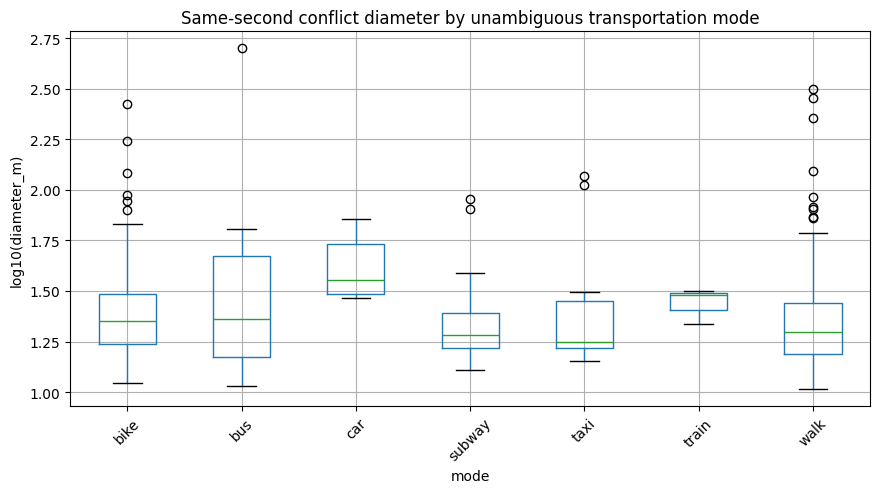

In [5]:
labeled = audit[audit["label_status"] == "unambiguous_mode"].copy()

mode_summary = (
    labeled.groupby("mode")
    .agg(
        groups=("mode","size"),
        median_radius_m=("max_radius_m","median"),
        p90_radius_m=("max_radius_m", lambda s: s.quantile(.90)),
        p99_radius_m=("max_radius_m", lambda s: s.quantile(.99)),
        max_radius_m=("max_radius_m","max"),
        median_diameter_m=("diameter_m","median"),
        p90_diameter_m=("diameter_m", lambda s: s.quantile(.90)),
        max_diameter_m=("diameter_m","max"),
    )
    .sort_values("groups", ascending=False)
)
display(mode_summary)

if not labeled.empty:
    plot_df = labeled.copy()
    plot_df["log10_diameter_m"] = np.log10(plot_df["diameter_m"].clip(lower=0.1))
    ax = plot_df.boxplot(column="log10_diameter_m", by="mode", rot=45, figsize=(10,5))
    ax.set_title("Same-second conflict diameter by unambiguous transportation mode")
    ax.set_ylabel("log10(diameter_m)")
    plt.suptitle("")
    plt.show()

### Cách đọc `mode_summary` và boxplot

Boxplot dùng `log10(diameter_m)` vì diameter có heavy tail. Mục tiêu không phải tìm một mode “đúng/sai”, mà xem các mode có nằm ở spatial scale khác nhau hay không.

#### Train — evidence rõ nhưng sample nhỏ

Run hiện tại:

| Metric | Giá trị |
|---|---:|
| groups | **3** |
| median diameter | **30.08m** |
| max diameter | **31.66m** |

Ví dụ `diameter ≈ 31m`:

```text
same recorded second
P1 ------------------------------- P2
                ~31m
```

Nếu elapsed time thật gần 1 giây thì 31m tương đương khoảng `31 × 3.6 ≈ 112 km/h`, nằm trong scale đã quan sát được cho train.

**Nhưng ta không biết elapsed time thật là 0.9s, 0.5s hay nhỏ hơn**, nên không được kết luận “đây chắc chắn là chuyển động thật”.

Điều ta có thể kết luận là:

> Một train-labeled same-second group >10m **không bắt buộc phải là corruption**. Timestamp quantization là một explanation khả dĩ.

#### Subway — phần lớn nhỏ, nhưng vài case không giải thích được bằng ordinary subway motion

Run hiện tại:

- 25 groups;
- median diameter ≈ **19.07m**;
- p90 ≈ **38.59m**;
- max ≈ **89.80m**.

Audited V3 subway p99 trước đây ≈ **94.32 km/h ≈ 26.2m/s**.

Trong 25 subway groups:
- **20** có diameter ≤ khoảng **25m** và nằm gần 1-second p99 scale;
- **5** lớn hơn rõ rệt, gồm các case khoảng 36–90m.

Vì vậy subway cho evidence dạng **mixture**:

```text
nhiều case: compatible với fast movement + timestamp quantization
một số case: cần explanation khác / stronger anomaly
```

Đặc biệt, `89.8m` **không nên gọi là “bình thường cho subway”**. Nếu xảy ra trong <1s thì required speed rất cao. Nó chỉ cho thấy ta cần giữ semantics conservative thay vì tự động merge.

#### Walk và bike — cho thấy `>10m` không thể chỉ được giải thích bằng movement

Run hiện tại:

```text
walk: median diameter ≈ 19.9m, max ≈ 314m
bike: median diameter ≈ 22.5m, max ≈ 266m
```

Một số values này lớn hơn nhiều so với plausible movement trong <1s. Vì vậy 835 groups có thể là hỗn hợp:

```text
same-second >10m
      │
      ├─ legitimate movement + timestamp quantization
      ├─ GPS jitter / measurement noise
      ├─ device batching / logging artifact
      ├─ interleaving / timestamp anomaly
      └─ genuine data corruption
```

### Kết luận của section 4

Không được suy:

```text
>10m → fast movement
```

và cũng không được suy:

```text
>10m → corruption
```

Evidence chỉ hỗ trợ:

```text
>10m → nguyên nhân chưa xác định, không còn safe để collapse
```

## 5. Spatial bins × mode

`333.3m` là displacement trong 1 giây tại hard guard 1200 km/h. Đây chỉ là diagnostic envelope, **không phải threshold mới**.

In [6]:
bins = [10,25,50,100,333.333333,1000,np.inf]
bin_labels = ["10-25m","25-50m","50-100m","100-333m","333m-1km",">1km"]

audit["diameter_bin"] = pd.cut(audit["diameter_m"], bins=bins, labels=bin_labels, right=True)
audit["mode_or_status"] = audit["mode"].where(
    audit["label_status"]=="unambiguous_mode",
    audit["label_status"],
)

display(pd.crosstab(audit["mode_or_status"], audit["diameter_bin"], margins=True))

under_guard = audit["diameter_m"] <= (1200.0/3.6)
print("All >10m conflict groups:", len(audit))
print("Diameter <=333.3m:", int(under_guard.sum()), f"({under_guard.mean():.2%})")

fast = audit[
    (audit["label_status"]=="unambiguous_mode")
    & audit["mode"].isin({"airplane","train","subway"})
].copy()

print("Unambiguous airplane/train/subway groups:", len(fast))
if len(fast):
    display(fast.sort_values("diameter_m", ascending=False)[
        ["user_id","trajectory_id","timestamp","mode","group_size","max_radius_m","diameter_m"]
    ].head(50))

diameter_bin,10-25m,25-50m,50-100m,100-333m,333m-1km,>1km,All
mode_or_status,,,,,,,
bike,92,35,15,3,0,0,145
bus,10,6,2,0,1,0,19
car,0,5,2,0,0,0,7
labeled_user_unlabeled_time,163,51,19,36,16,64,349
subway,20,3,2,0,0,0,25
taxi,7,1,0,2,0,0,10
train,1,2,0,0,0,0,3
unlabeled_user,27,8,24,17,3,4,83
walk,134,46,10,4,0,0,194


All >10m conflict groups: 835
Diameter <=333.3m: 747 (89.46%)
Unambiguous airplane/train/subway groups: 28


Exact user/trajectory/timestamp sample rows omitted from committed notebook for privacy.


### Cách đọc spatial bins và mốc 333.3m

`333.3m` bắt nguồn từ hard-speed guard hiện tại:

\[
1200\text{ km/h} / 3.6 = 333.3\text{ m/s}
\]

Run hiện tại:

```text
747 / 835 = 89.46%
```

groups có `diameter <= 333.3m`.

**Đây không có nghĩa 89.46% groups là valid.** Nó chỉ nói rằng phần lớn groups không vượt qua một broad physical/engineering envelope cực kỳ rộng.

Ví dụ:

```text
walk diameter = 300m
```

vẫn `<333.3m`, nhưng rõ ràng không thể được giải thích bằng ordinary walking trong <1s.

Ngược lại:

```text
88 / 835 groups >333.3m
```

trong đó:
- 20 groups ở `333m–1km`;
- 68 groups `>1km`.

Các case này là **strong spatial inconsistency candidates**.

Một observation đáng chú ý trong run này: toàn bộ `>1km` cases nằm ở `unlabeled_user` hoặc `labeled_user_unlabeled_time`; không có `>1km` case nào trong nhóm unambiguous transportation mode. Điều đó hữu ích về mặt mô tả, nhưng không đủ để kết luận mode label “bảo đảm validity” vì label coverage chỉ có trên một phần dữ liệu.

### Vì sao vẫn giữ 10m chứ không tăng lên 333m?

Hai threshold trả lời hai câu hỏi khác nhau:

```text
10m     → group có đủ compact để safe-to-collapse thành median không?
333.3m  → broad diagnostic envelope dưới hard guard 1200 km/h
```

`333.3m` tuyệt đối **không** phải candidate consolidation threshold.

## 6. Diagnostic compatibility với audited transport-speed evidence

Ta lấy speed reference từ V3 transportation benchmark trước đây và đổi sang “distance trong 1 giây”:

| mode | reference | approx distance / 1s |
|---|---:|---:|
| airplane | observed max 1048.11 km/h | 291.1m |
| train | p99 210.34 km/h | 58.4m |
| taxi | p99 104.75 km/h | 29.1m |
| subway | p99 94.32 km/h | 26.2m |
| car | p99 119.63 km/h | 33.2m |
| bus | p99 90.59 km/h | 25.2m |
| bike | p99 40.63 km/h | 11.3m |
| walk | p99 40.39 km/h | 11.2m |

Reference này chỉ là **diagnostic context**, không phải validity rule. Đặc biệt walk/bike p99 tail có thể chứa noise/anomaly nên không được đọc như physical ground truth.

Ta hỏi:

> Với một mode, bao nhiêu same-second conflicts có `diameter_m <= reference_1s_m`?

Nếu tỷ lệ cao, timestamp quantization là một explanation khả dĩ cho nhiều case. Nếu tỷ lệ thấp, movement bình thường không giải thích được phần lớn spread.

In [7]:
reference_kmh = {
    "airplane": 1048.11,  # observed max in audited V3
    "train": 210.34,      # p99
    "taxi": 104.75,       # p99
    "subway": 94.32,      # p99
    "car": 119.63,        # p99
    "bus": 90.59,         # p99
    "bike": 40.63,        # p99
    "walk": 40.39,        # p99; diagnostic only
}

diag = labeled[labeled["mode"].isin(reference_kmh)].copy()
diag["reference_kmh"] = diag["mode"].map(reference_kmh)
diag["reference_1s_m"] = diag["reference_kmh"] / 3.6
diag["within_reference_1s"] = diag["diameter_m"] <= diag["reference_1s_m"]

compat = (
    diag.groupby("mode")
    .agg(
        groups=("mode","size"),
        reference_1s_m=("reference_1s_m","first"),
        within_reference_groups=("within_reference_1s","sum"),
        within_reference_rate=("within_reference_1s","mean"),
        median_diameter_m=("diameter_m","median"),
        max_diameter_m=("diameter_m","max"),
    )
)
display(compat)

,groups,reference_1s_m,within_reference_groups,within_reference_rate,median_diameter_m,max_diameter_m
mode,,,,,,
bike,145,11.286111,2,0.013793,22.513739,266.283532
bus,19,25.163889,10,0.526316,22.948726,499.708829
car,7,33.230556,3,0.428571,35.819217,71.397950
subway,25,26.200000,20,0.800000,19.074184,89.798735
taxi,10,29.097222,7,0.700000,17.781247,117.179122
train,3,58.427778,3,1.000000,30.081463,31.656034
walk,194,11.219444,4,0.020619,19.891006,314.178381


### Cách diễn giải compatibility table

Từ run hiện tại trước khi bổ sung `subway`/`taxi` vào table:

- **train:** `3/3 = 100%` nằm trong reference 1-second scale → strongest observed evidence rằng `>10m` không đồng nghĩa corruption;
- **bus:** `10/19 ≈ 52.6%` → mixture;
- **car:** `3/7 ≈ 42.9%` → mixture;
- **bike:** `2/145 ≈ 1.4%`;
- **walk:** `4/194 ≈ 2.1%`.

Sau khi rerun cell trên, table sẽ có thêm `subway` và `taxi`.

Với raw subway rows của run hiện tại, **20/25 = 80%** có diameter ≤ `26.2m`, tức nằm trong 1-second scale từ subway p99 reference. 5/25 còn lại lớn hơn rõ rệt.

Điều này tạo pattern rất hữu ích:

```text
train / nhiều subway cases
→ movement + timestamp quantization là explanation khả dĩ

walk / bike phần lớn cases
→ ordinary movement không đủ để giải thích spread
```

Vì vậy population `>10m` là **heterogeneous mixture**, và transportation mode chỉ giúp ta nhìn thấy mixture đó; nó không được dùng để repair/order points.

## 7. Kết luận audit và implication cho cleaning contract

### Kết luận chính

Audit hỗ trợ cách hiểu mới:

> **10m là `safe-to-collapse threshold`, không phải `valid-vs-corrupt threshold`.**

Cụ thể:

```text
same-second max_radius <= 10m
→ group đủ compact
→ safe to consolidate bằng robust median representative

same-second max_radius > 10m
→ không còn safe để collapse
→ within-second ordering không identifiable
→ tạo continuity boundary
→ không tự động kết luận nguyên nhân là corruption
```

### Evidence nào dẫn tới kết luận này?

1. Trong 835 groups >10m, 403 có transportation mode unambiguous.
2. Không có airplane case unambiguous, nên airplane vẫn là motivating theoretical example chứ chưa phải observed evidence.
3. Cả 3 train cases chỉ có diameter khoảng 22–32m và `3/3` nằm trong train 1-second reference scale.
4. 25 subway cases có median diameter ≈19m; 20/25 nằm trong ~26.2m 1-second p99 scale, nhưng một số case lớn tới ~90m.
5. Walk/bike có rất nhiều >10m cases mà ordinary movement không giải thích được.
6. 68 groups có diameter >1km và là strong spatial inconsistency candidates.

Tổng hợp:

```text
>10m groups = mixture of possible causes
```

nên tên/diễn giải “spatial corruption” cho toàn bộ tail là quá mạnh.

### Điều audit KHÔNG chứng minh

Audit không chứng minh rằng:

- mọi group >10m là valid;
- mọi group >10m là fast movement;
- airplane đang gây ra conflict trong 835 groups hiện tại;
- threshold nên tăng từ 10m lên 50m, 100m hay 333m;
- transportation labels nên trở thành runtime feature.

### Điều nên thay đổi

**Scientific semantics / diagnostics:**

Tên trung tính hơn nên là dạng:

```text
same_second_spatial_ambiguity
```

hoặc:

```text
same_second_unresolved_spread
```

thay cho wording ngầm khẳng định corruption.

### Điều KHÔNG cần thay đổi

Production behavior vẫn có thể giữ nguyên:

```text
<=10m  → median-collapse
>10m   → discard unresolved timestamp from retained sequence + continuity boundary
```

Lý do giữ boundary không phải vì ta biết data hỏng, mà vì ta **không biết within-second order**, nên bridging qua timestamp đó có thể invent một trajectory giả.

Stay-point baseline cũng không cần rerun chỉ vì đổi semantics, vì sequence boundaries không thay đổi.

### Contract statement đề xuất

> The 10 m threshold is a safe-consolidation threshold rather than a validity threshold. Same-second groups exceeding 10 m are not collapsed because within-second ordering is unidentifiable at GeoLife's released timestamp precision. Transportation-mode evidence shows that some >10 m groups are compatible with legitimate movement, while other groups exhibit much stronger spatial inconsistency. Therefore these groups remain continuity boundaries but should be described as unresolved same-second spatial ambiguity rather than automatically as corruption.

### Next step

Amend Stage 2 contract + diagnostic reason wording, update tests/notebooks for the renamed semantics, then run CI. **Không cần chạy lại full baseline hoặc sensitivity grid nếu boundary behavior không đổi.**